In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [ ]:
class BMIState(TypedDict):

  weight_kg : float
  height_m : float
  bmi : float
  category: str

In [6]:
def calculate_bmi(state:BMIState) -> BMIState:


  weight=state['weight_kg']
  height=state['height_m']

  bmi = weight/(height**2)
  state['bmi']=round(bmi,2)

  return state



In [12]:
def get_bmi_category(state: BMIState) -> BMIState:
  bmi = state['bmi']
  if bmi < 18.5:
    state["category"] = "Underweight"
  elif 18.5 <= bmi < 25:
    state ["category"] = "Normal"
  elif 25 <= bmi < 30:
    state ["category"] = "Overweight"
  else:
    state ["category"] = "Obese"
  return state

In [ ]:
# Define Graph

graph= StateGraph(BMIState)

# add nodes

graph.add_node("calculate bmi",calculate_bmi)
graph.add_node("label bmi", get_bmi_category)

# add edges

graph.add_edge(START, 'calculate bmi')
graph.add_edge('calculate bmi', 'label bmi')
graph.add_edge('label bmi', 'END')



#compile graph
workflow = graph.compile()



In [9]:
#execute graph
initial_state = {'weight_kg':90, 'height_m':1.73}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 90, 'height_m': 1.73, 'bmi': 30.07}


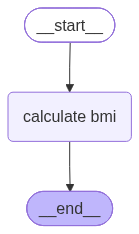

In [10]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))
